# 03: Bayesian Optimization Landscape
**Objective:** Parse the hyperopt `Trials` checkpoint files (`.pkl`) to visualize how the Tree-structured Parzen Estimator (TPE) navigated the 8-dimensional hyperparameter spaces to find the global mathematical minimums for our base models.

In [72]:
import pickle
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from hyperopt import Trials

# Load base config FIRST
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

# Dynamically extract zones to prevent manual desync
TARGET_ZONES = config["data"]["target_zones"]

# Load your new SOTA artifact
with open('../best_hyperparameters.yaml', 'r') as f:
    best_params = yaml.safe_load(f)

trials_dir = Path('../') / config.get('model_settings', {}).get('hyperopt', {}).get('trials_dir', 'data/outputs/trials/')

# Loop through every country!
for zone in TARGET_ZONES:
    print("\n" + "="*50)
    print(f"🏆 === SOTA Hyperparameters for {zone} ===")
    print("="*50)
    
    for model_name, zones_dict in best_params.items():
        if zone in zones_dict:
            print(f"\n[{model_name}]")
            for k, v in zones_dict[zone].items():
                print(f"  {k}: {v}")
                
    zone_trials_dir = trials_dir / zone
    print(f"\n📂 Trials directory for {zone}: {zone_trials_dir}")


🏆 === SOTA Hyperparameters for AT ===

[CatBoost]
  depth: 6.0
  l2_leaf_reg: 13.361935914443565
  learning_rate: 0.018493317851785162
  n_estimators: 1500
  random_strength: 1.5047718879708099

[LightGBM]
  colsample_bytree: 0.8073912294490804
  learning_rate: 0.0074827569478912925
  n_estimators: 1500
  num_leaves: 21.0
  reg_alpha: 0.09069301645046507
  reg_lambda: 1.9504469694420405
  subsample: 0.5478672542487738

[PyTorch DNN]
  batch_size: 64
  dropout_rate: 0.2839910933561667
  lr: 0.00030893022914867883
  weight_decay: 0.00019283087446531297

[RandomForest]
  max_depth: 10.0
  min_samples_leaf: 6.0
  min_samples_split: 7.0
  n_estimators: 300

[XGBoost]
  colsample_bytree: 0.9797652467353405
  learning_rate: 0.005058795555024722
  max_depth: 5.0
  min_child_weight: 2.0
  n_estimators: 1500
  reg_alpha: 0.42879900874592086
  reg_lambda: 0.0013561216204075355
  subsample: 0.5007252062645492

📂 Trials directory for AT: ..\data\outputs\trials\AT

🏆 === SOTA Hyperparameters for BE

## 1. LightGBM Optimization Trajectory
Let's see if the TPE algorithm successfully converged, or if it was still randomly exploring when it hit `max_evals`.

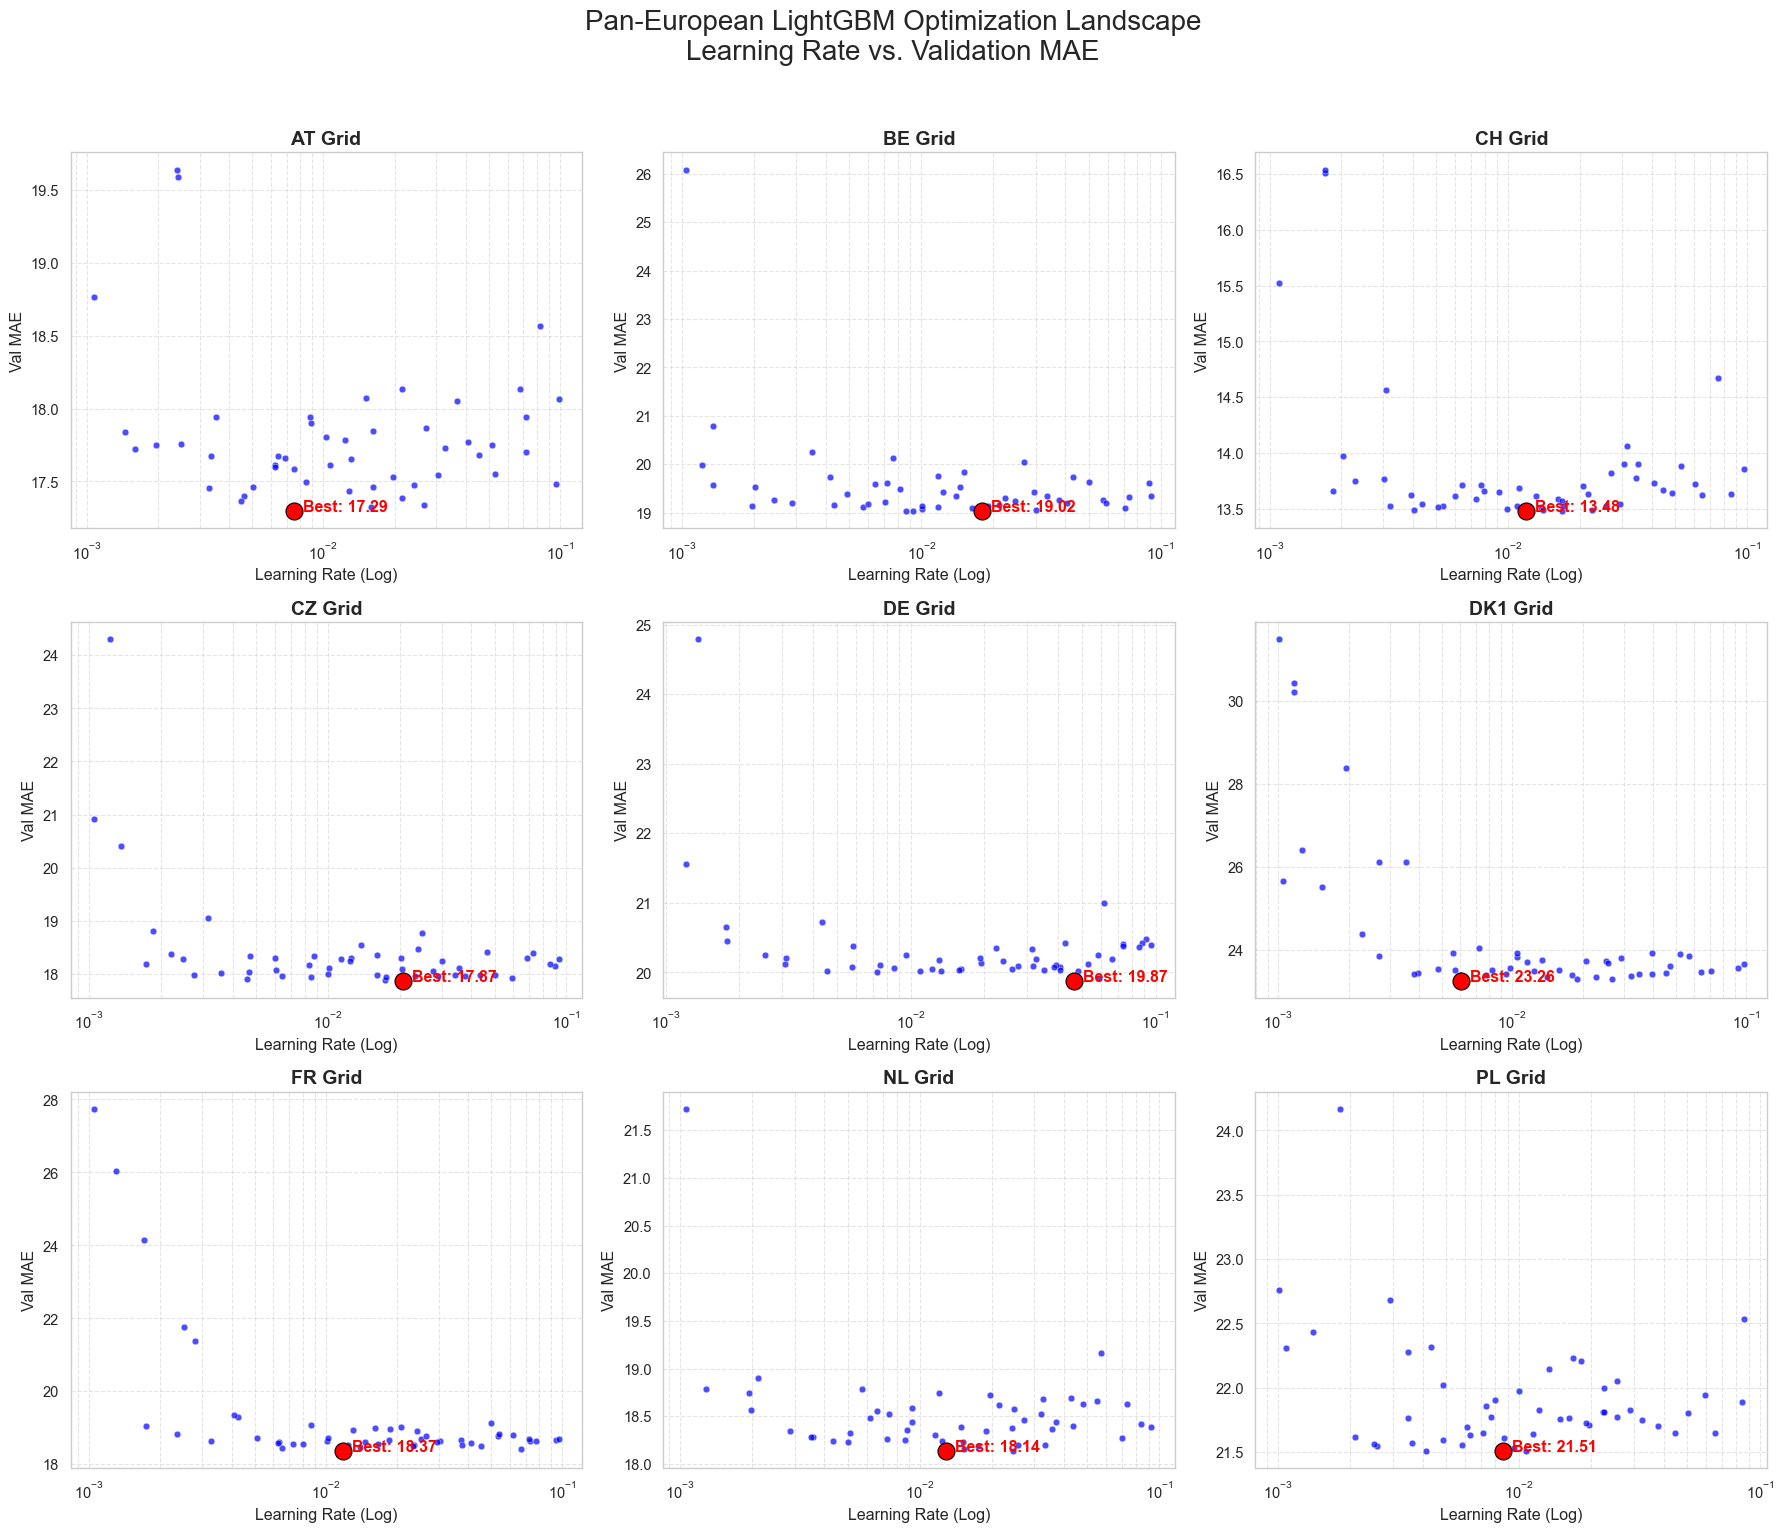

In [73]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Pan-European LightGBM Optimization Landscape\nLearning Rate vs. Validation MAE', fontsize=20, y=1.02)

for ax, zone in zip(axes.flatten(), TARGET_ZONES):
    ckpt_path_lgb = trials_dir / zone / 'lgb_trials.pkl'
    
    if ckpt_path_lgb.exists():
        with open(ckpt_path_lgb, 'rb') as f:
            lgb_trials = pickle.load(f)

        lgb_results = []
        for trial in lgb_trials.trials:
            if trial['result']['status'] == 'ok':
                vals = trial['misc']['vals']
                loss = trial['result']['loss']
                
                lr = vals.get('lgb_lr', [None])[0]
                if lr is not None:
                    lgb_results.append({'learning_rate': lr, 'loss': loss})

        if lgb_results:
            lgb_df = pd.DataFrame(lgb_results)
            
            sns.scatterplot(data=lgb_df, x='learning_rate', y='loss', alpha=0.7, color='blue', ax=ax)
            ax.set_xscale('log')
            ax.set_title(f'{zone} Grid', fontsize=14, fontweight='bold')
            ax.set_xlabel('Learning Rate (Log)')
            ax.set_ylabel('Val MAE')
            ax.grid(True, which="both", ls="--", alpha=0.5)
            
            # Highlight minimum
            min_row = lgb_df.loc[lgb_df['loss'].idxmin()]
            ax.scatter(min_row['learning_rate'], min_row['loss'], color='red', s=150, edgecolor='black', zorder=5)
            ax.text(min_row['learning_rate'], min_row['loss'], f"  Best: {min_row['loss']:.2f}", color='red', fontweight='bold')
        else:
            ax.set_title(f'{zone} (Empty Trials)')
    else:
        ax.set_title(f'{zone} (No Checkpoint Found)')
        ax.axis('off')

plt.tight_layout()
plt.show()

## 2. Dynamic Optimization Landscapes
This engine dynamically reads the trial logs for any evaluated architecture and plots its convergence trajectory alongside its most critical hyperparameter interactions (Learning Rate vs. Complexity).

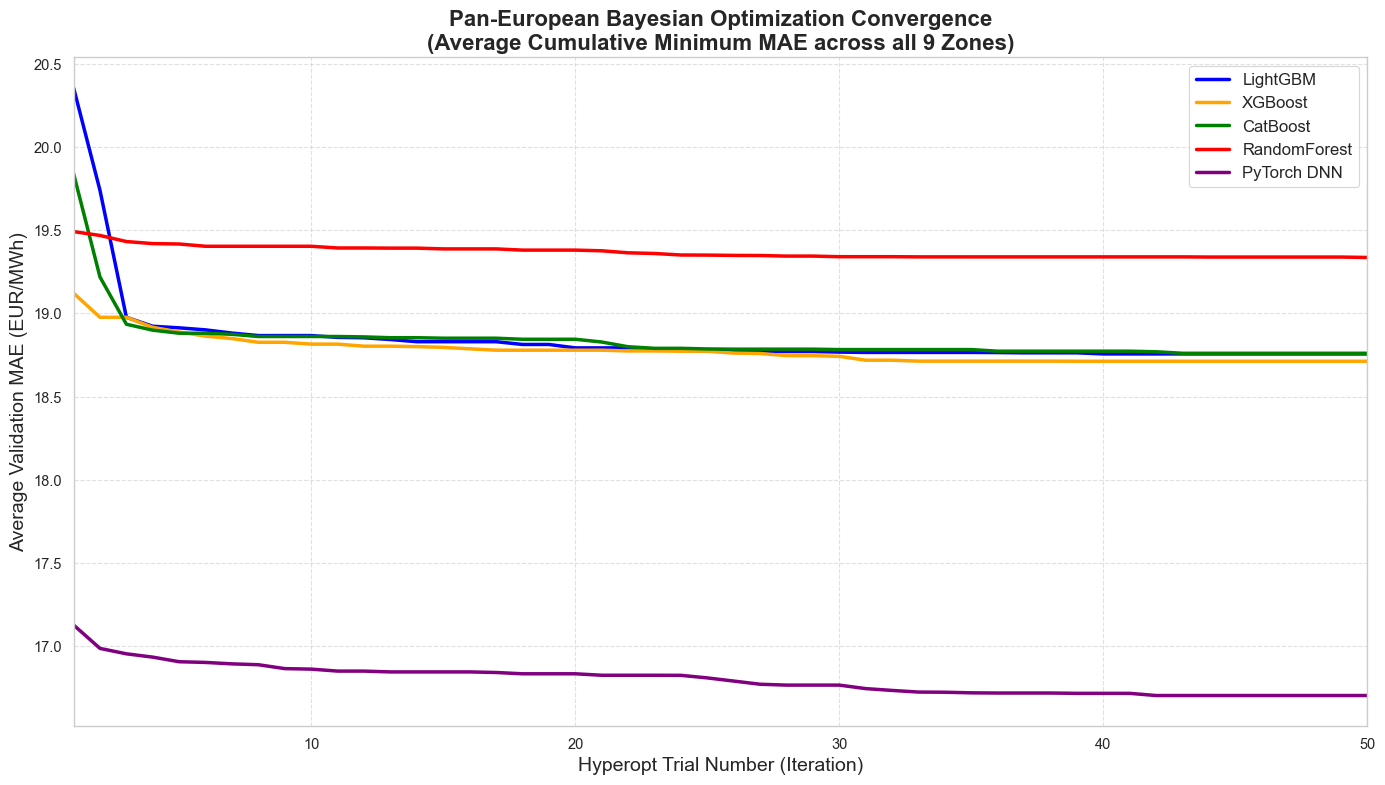

In [74]:
# ==========================================
# Pan-European Convergence Analysis
# ==========================================
models_dict = {
    'LightGBM': ('lgb', 'blue'),
    'XGBoost': ('xgb', 'orange'),
    'CatBoost': ('cat', 'green'),
    'RandomForest': ('rf', 'red'),
    'PyTorch DNN': ('dnn', 'purple')
}

plt.figure(figsize=(14, 8))

for model_name, (prefix, color) in models_dict.items():
    all_zones_cummin = []
    
    for zone in TARGET_ZONES:
        ckpt_path = trials_dir / zone / f'{prefix}_trials.pkl'
        
        if ckpt_path.exists():
            with open(ckpt_path, 'rb') as f:
                trials = pickle.load(f)
                
            # Sort trials chronologically by their ID (tid)
            sorted_trials = sorted(trials.trials, key=lambda x: x['tid'])
            
            # Extract the loss for successful trials
            losses = [t['result']['loss'] for t in sorted_trials if t['result']['status'] == 'ok']
            
            if losses:
                # Calculate the "best loss found so far" at each iteration
                cummin = np.minimum.accumulate(losses)
                all_zones_cummin.append(cummin)
    
    if all_zones_cummin:
        # Align lengths in case some zones crashed or stopped early
        min_len = min(len(c) for c in all_zones_cummin)
        truncated_cummin = [c[:min_len] for c in all_zones_cummin]
        
        # Calculate the Pan-European Average Convergence
        avg_cummin = np.mean(truncated_cummin, axis=0)
        
        plt.plot(range(1, min_len + 1), avg_cummin, label=model_name, color=color, linewidth=2.5)

plt.title('Pan-European Bayesian Optimization Convergence\n(Average Cumulative Minimum MAE across all 9 Zones)', fontsize=16, fontweight='bold')
plt.xlabel('Hyperopt Trial Number (Iteration)', fontsize=14)
plt.ylabel('Average Validation MAE (EUR/MWh)', fontsize=14)
plt.grid(True, ls="--", alpha=0.6)
plt.legend(fontsize=12, loc='upper right')
plt.xlim(1, 50) # Assuming 50 max_evals
plt.tight_layout()
plt.show()

## 3. Deep Neural Network (PyTorch) Landscape
Neural networks are notoriously sensitive to learning rate and dropout. Let's visualize how the optimizer navigated the Adam optimizer's learning rate against the regularization dropout penalty.

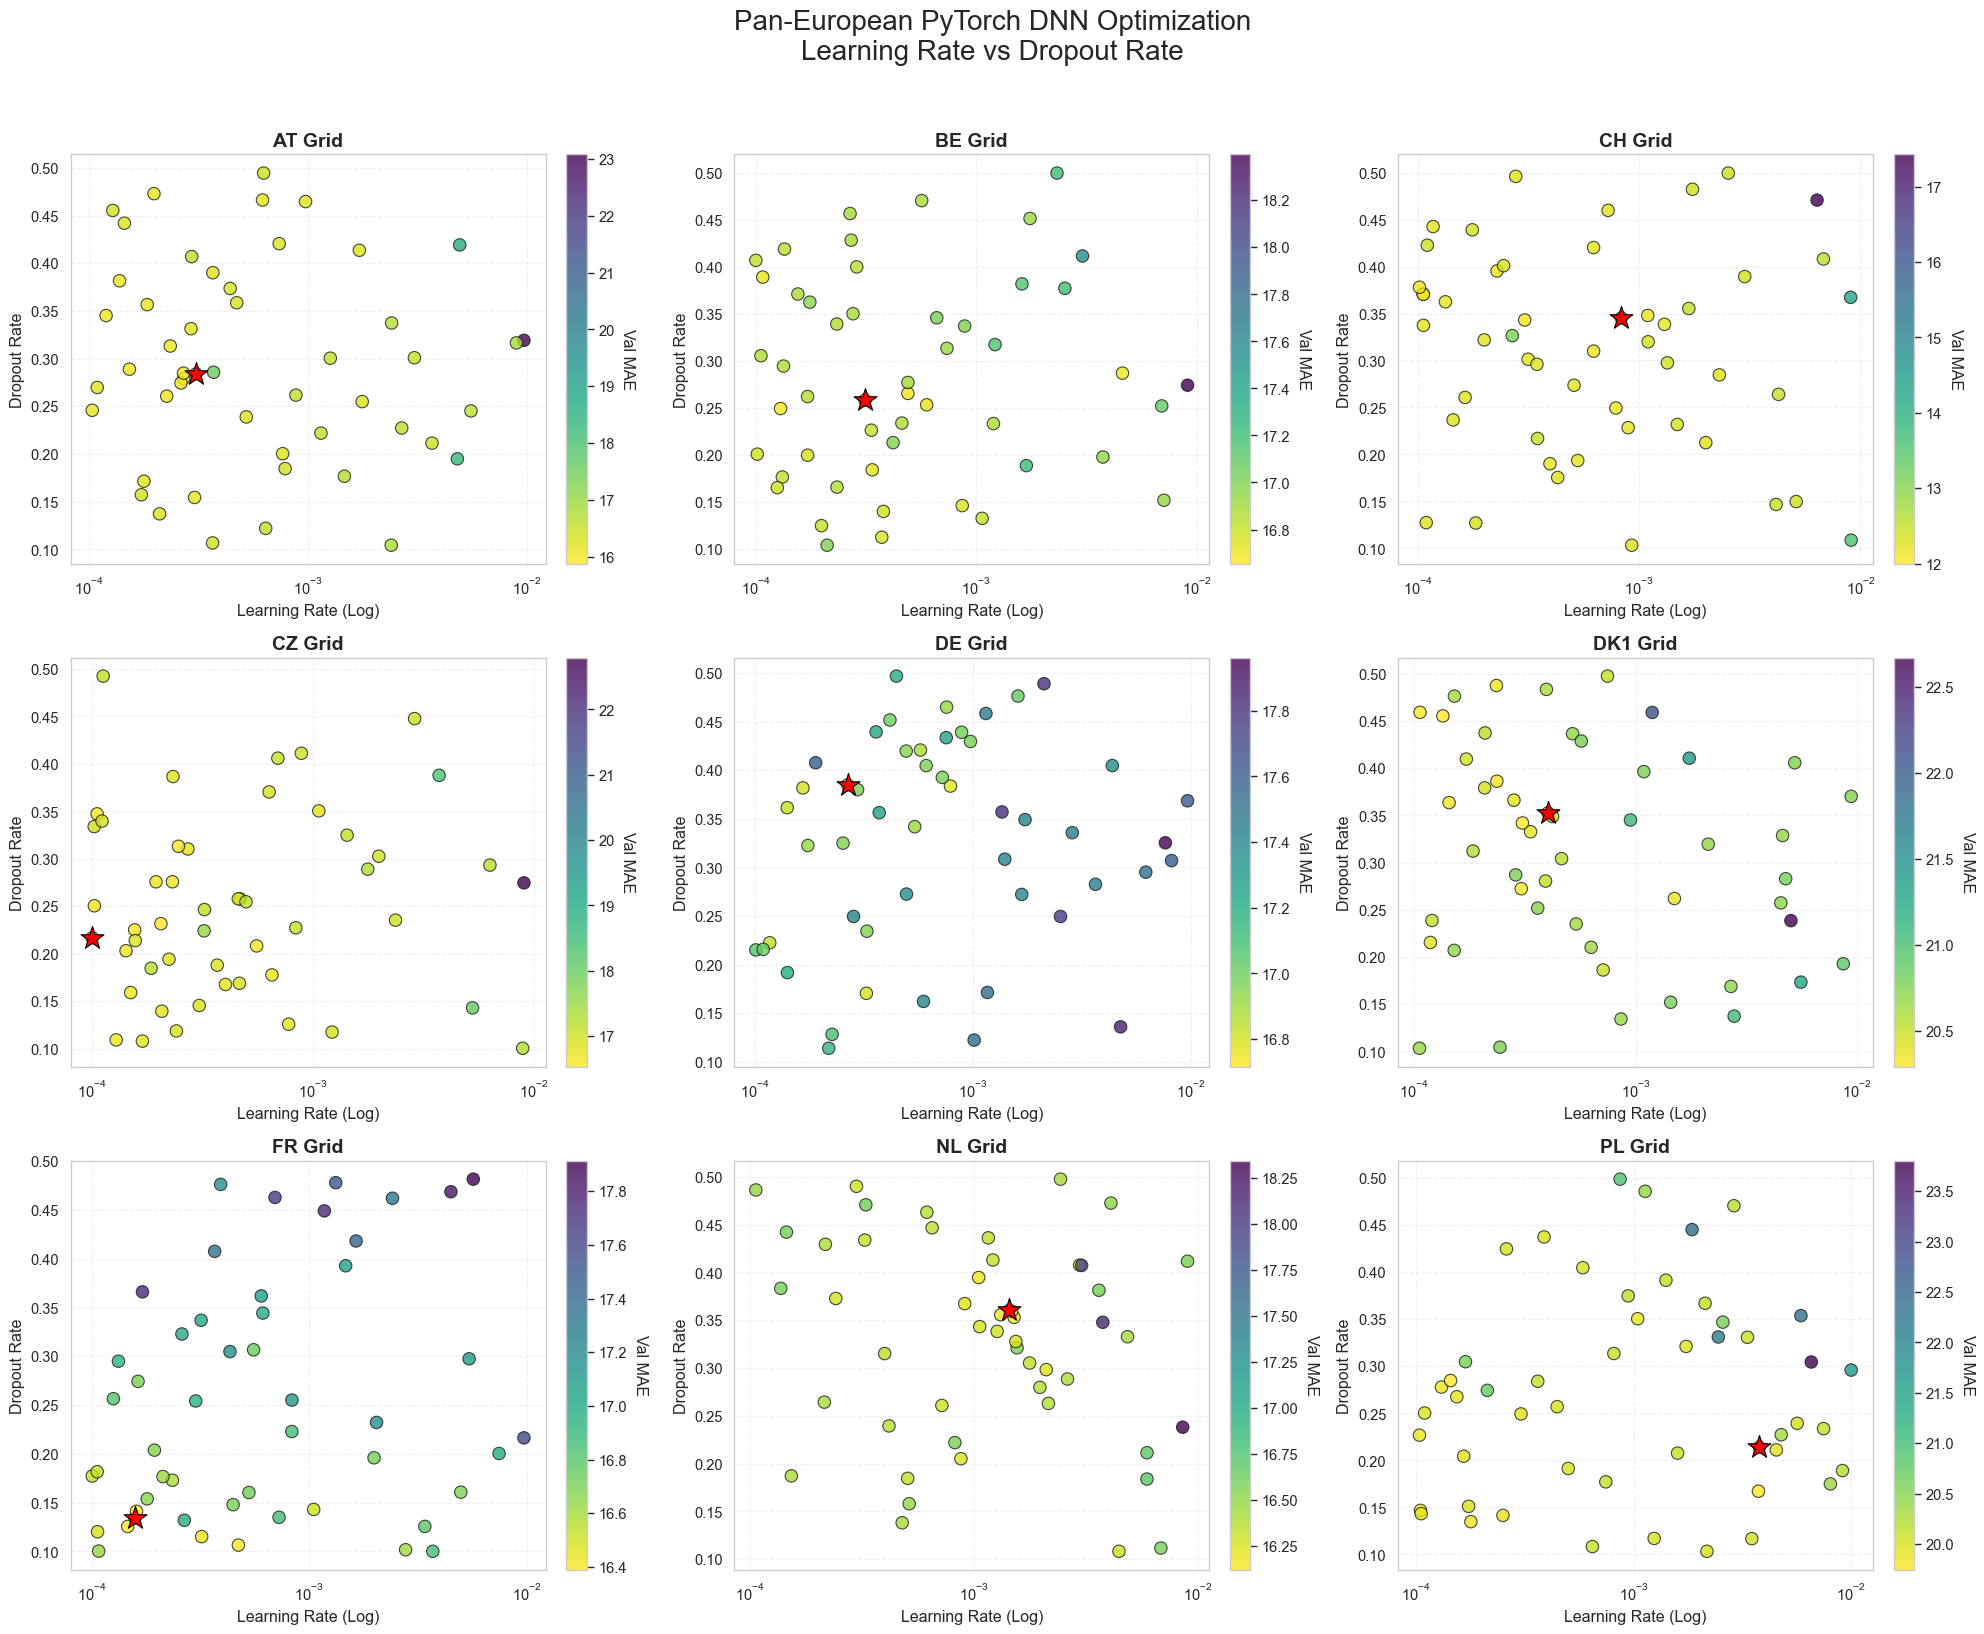

In [75]:
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('Pan-European PyTorch DNN Optimization\nLearning Rate vs Dropout Rate', fontsize=20, y=1.02)

for ax, zone in zip(axes.flatten(), TARGET_ZONES):
    ckpt_path_dnn = trials_dir / zone / 'dnn_trials.pkl'
    
    if ckpt_path_dnn.exists():
        with open(ckpt_path_dnn, 'rb') as f:
            dnn_trials = pickle.load(f)

        dnn_results = []
        for trial in dnn_trials.trials:
            if trial['result']['status'] == 'ok':
                vals = trial['misc']['vals']
                loss = trial['result']['loss']
                
                lr = vals.get('dnn_lr', [None])[0]
                dropout = vals.get('dnn_drop', [None])[0]
                
                if lr is not None and dropout is not None:
                    dnn_results.append({
                        'learning_rate': lr, 
                        'dropout_rate': dropout, 
                        'loss': loss
                    })

        if dnn_results:
            dnn_df = pd.DataFrame(dnn_results)
            
            scatter = ax.scatter(dnn_df['learning_rate'], dnn_df['dropout_rate'], 
                                 c=dnn_df['loss'], cmap='viridis_r', s=80, alpha=0.8, edgecolor='k')
            
            ax.set_xscale('log')
            ax.set_title(f'{zone} Grid', fontsize=14, fontweight='bold')
            ax.set_xlabel('Learning Rate (Log)')
            ax.set_ylabel('Dropout Rate')
            ax.grid(True, ls="--", alpha=0.3)
            
            # Highlight minimum
            min_row = dnn_df.loc[dnn_df['loss'].idxmin()]
            ax.scatter(min_row['learning_rate'], min_row['dropout_rate'], color='red', marker='*', s=300, edgecolor='black')
            
            # Add colorbar specifically for this subplot
            cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label('Val MAE', rotation=270, labelpad=15)
        else:
            ax.set_title(f'{zone} (Empty Trials)')
    else:
        ax.set_title(f'{zone} (No Checkpoint Found)')
        ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Final Base Model Showdown
Which architecture ultimately won the Point Forecasting phase before entering the Ensemble?

C:\Users\mathi\AppData\Local\Temp\ipykernel_53564\529770794.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(best_scores.keys()), y=list(best_scores.values()), palette='mako')


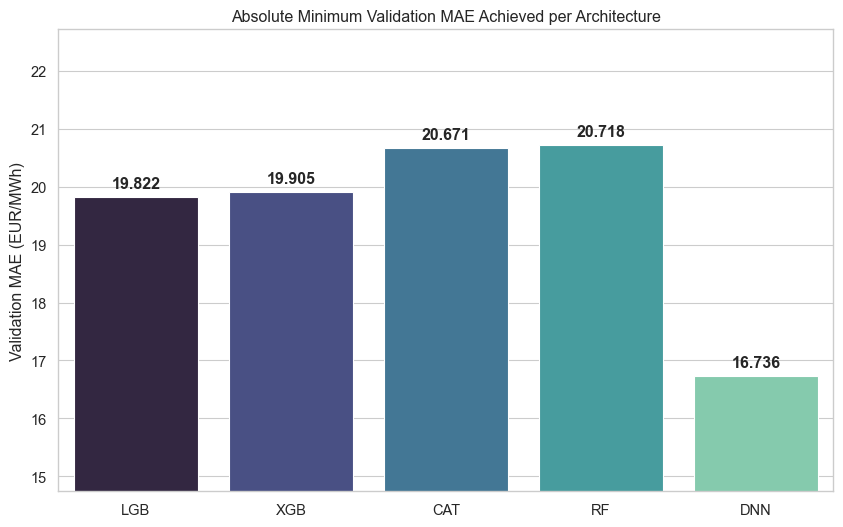

In [76]:
models = ['lgb', 'xgb', 'cat', 'rf', 'dnn']
best_scores = {}

for m in models:
    df = parse_trials(os.path.join(TRIALS_DIR, f'{m}_trials.pkl'), CHOICE_MAPPINGS)
    if not df.empty:
        best_scores[m.upper()] = df['val_mae'].min()

if best_scores:
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=list(best_scores.keys()), y=list(best_scores.values()), palette='mako')
    
    # Annotate bars
    for i, v in enumerate(best_scores.values()):
        ax.text(i, v + 0.1, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
        
    plt.title('Absolute Minimum Validation MAE Achieved per Architecture')
    plt.ylabel('Validation MAE (EUR/MWh)')
    plt.ylim(min(best_scores.values()) - 2, max(best_scores.values()) + 2) # Zoom in to see the margins
    plt.show()